# ***ANALISIS DESCRIPTIVO***
---
El dataset 'customer_shopping_data' nos da tablas bastante útiles para realizar un analisis de mercado, ya que nos proporciona las siguientes tablas:

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('customer_shopping_data.csv')
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


Tras esto, nos interesa saber
- ¿Que tipo de datos contiene?
- ¿Hay valores nulos?
Por ello primero que nada debemos hacer un EDA de forma que:

#### Resumen estadistico

In [3]:
df.describe()

,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


#### Resumen tecnico

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


#### Busqueda de nulos

In [10]:
df.isnull().sum()

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

De esto podemos sacar varias cosas, tales como: 
- No hay ningún valor nulo.
- Existen 3 columnas de tipo numerico las cuales son 'age' 'quantity' 'price'.
- El promedio de edad de los clientes es de 43 años.
- En promedio llevan 3 productos.
- En promedio el valor que llevan es de al rededor de 600.

Estos datos por si solos ya son interesantes, pero aún se puede llegar a hacer un analisis más extenso, como la relacion que tienen los datos entre si.

Para ello, primero realizamos un mapa de calor de forma en que nos quedaria de la siguiente forma:

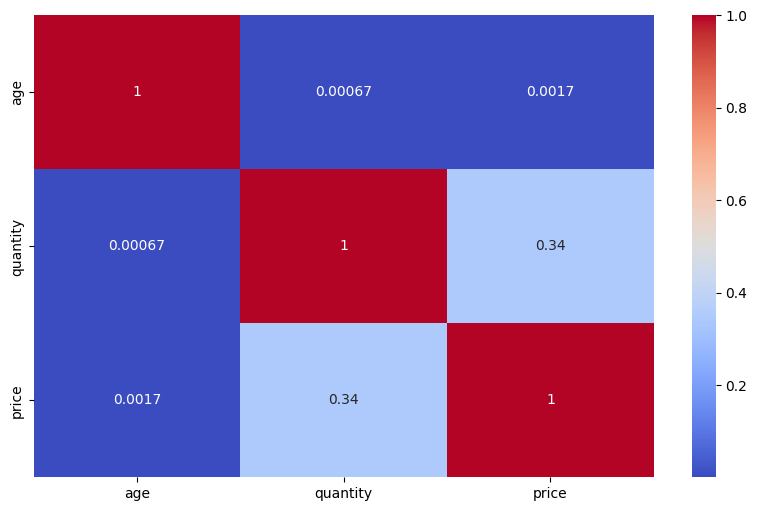

In [7]:
correlation = df.select_dtypes(include='number').corr()
plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.show()

Observamos que las correlaciones más altas estan dadas por **'price'** y **'quantity'** algo que nos da un indicio de que es buena idea analizarlo, mientras que el caso de la edad y el precio es realmente muy bajo, por lo que no vale la pena analizarlos realmente.

Sin embargo, en un sentido logico el hecho de que el precio aumente respecto a la cantidad de productos llevado por el cliente es algo logico, por lo que tendremos que optar por hacer un tipo diferente de analisis, en el cual incluyamos datos que no son precisamente un dato numerico, para lograr esto debemos hacer lo siguiente:


<Axes: xlabel='category'>

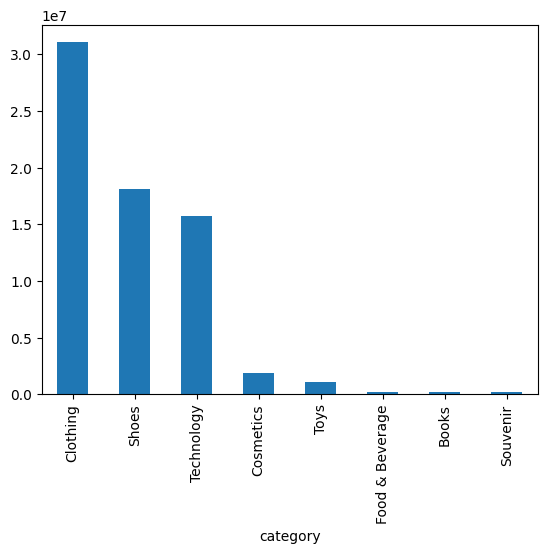

In [15]:
sales_by_cat = df.groupby("category")["price"].sum().sort_values(ascending=False)

sales_by_cat.plot(kind="bar")

Esto ya nos da bastantes datos, y es que al parecer la ropa es el producto más rentable, seguido por los zapatos y tecnologia, tras esto hay una caida considerable hasta los souvenir los cuales son el producto menos rentable.

Aún podemos analizar otros datos, tales como: 
- el genero y precio total de la compra.
- la cantidad de productos llevados y la tienda

<Axes: xlabel='gender'>

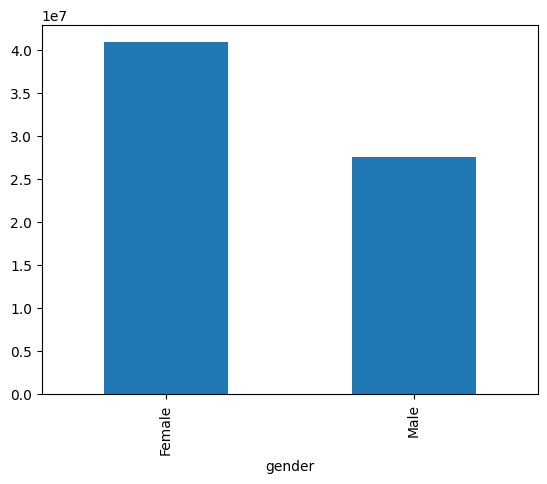

In [18]:
ventas_genero = df.groupby("gender")["price"].sum()
ventas_genero.plot(kind="bar")

Donde podemos ver que existe una clara diferencia donde por lo general, el genero feminino compra productos con mayor valor que el masculino. 

<Axes: xlabel='shopping_mall'>

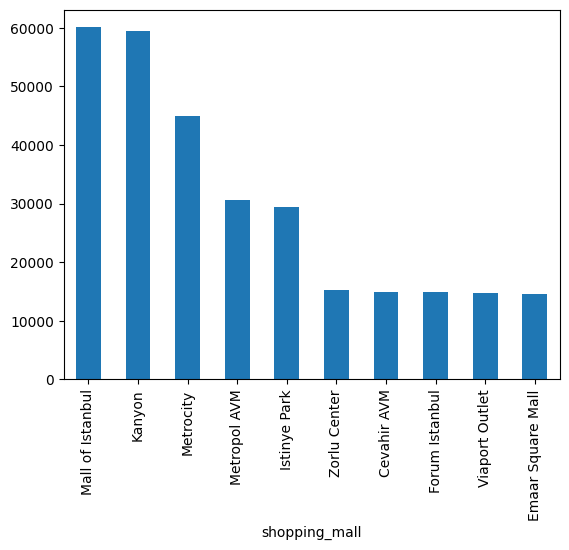

In [25]:
sales_gender = df.groupby("shopping_mall")["quantity"].sum().sort_values(ascending=False)
sales_gender.plot(kind="bar")

Este es bastante claro, ya que podemos ver 2 mall con mayores ventas siendo estas **'Kanyon'** y **'Mall of Istanbul'**, seguidas por 'Metrocity'.

Algo que nos da de que pensar sobre el a que se debe esta diferencia tan notable con respecto a las otras ubicaciones.

<Axes: xlabel='shopping_mall'>

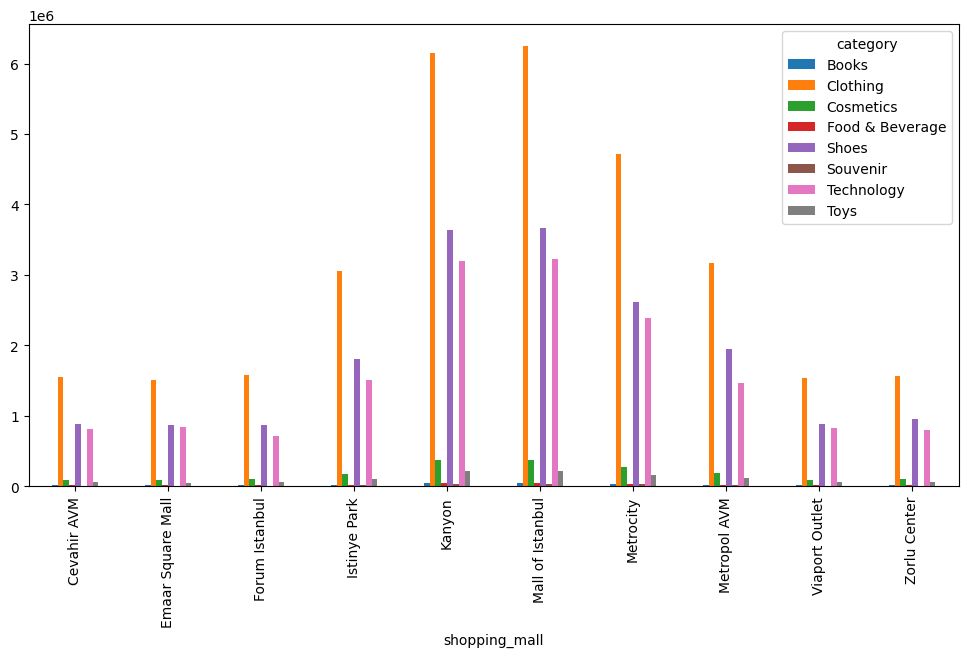

In [30]:
ventas_categoria_mall = df.groupby(["shopping_mall","category"])["price"].sum().unstack()
ventas_categoria_mall.plot(kind="bar", figsize=(12,6))

### Ventas a lo largo de los meses

<Axes: xlabel='invoice_date'>

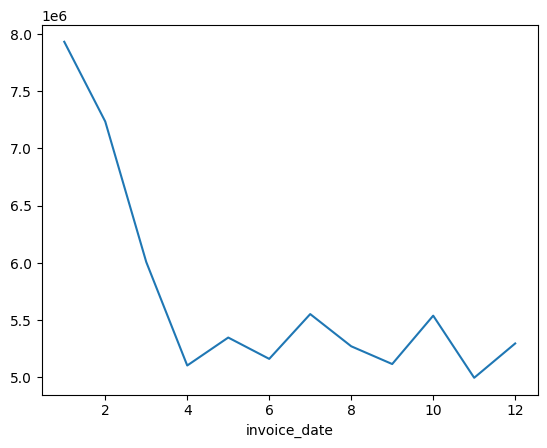

In [38]:
df["invoice_date"] = pd.to_datetime(df["invoice_date"], dayfirst=True)
ventas_mes = df.groupby(df["invoice_date"].dt.month)["price"].sum()
ventas_mes.plot()

## *Mejoras sugeridas*
---
El analisis dejo claras varias tendencias clave, lo que nos permite dar las siguientes recomendaciones basadas en los datos recogidos:

- Dada la tendencia de mayores ventas por parte del sector femenino, un movimiento bastante necesario es aumentar el tipo de productos femeninos, especialmente ropa siendo este el producto más vendido en todos los mall.
- Realmente no hay datos suficientes para determinar la clara diferencia en ventas de los mall de 'kanyon' y 'Mall of Istanbul', por lo que recomendaria hacer un estudio más a fondo con mayores datos para determinar que factor en especifico esta causando esta tendencia, principalmente para aplicar esto mismo al resto de malls que tienen unas ventas considerablemente menores.
- Concentrarse en productos para los meses de Diciembre, Enero y Febrero, ya que representan la mayor cantidad de ventas con respecto a otros meses. 

## **Conclusion**
---

Según los datos recopilados podemos sacar informacion bastante valiosa, se observa una gran inclinacion hacia la ropa y sobre todo una clara dominancia en el mercado por las personas adultas, especificamente de 30 años en adelante, por lo que, enfocarse en este publico puede aumentar las ventas y resultar más atractivo para la clientela regular. Aprendimos que el analisis de los datos puede mejorar un negocio al encontrar patrones y señales que nos indiquen por que lado puede haber mayor tendencia y donde enfocarnos.